# Lab 10: XAI

---

## Zadanie 1: Permutation feature importance 

---

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import os

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, StratifiedKFold
from torch.utils.data import DataLoader, WeightedRandomSampler

import matplotlib.pyplot as plt

import optuna
from tqdm import tqdm 

c:\Users\posze\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
X,y = make_classification(
    n_samples=5000,
    n_features=20,
    n_classes=4,
    n_informative=4,
    random_state=42
)

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2)

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
class Classifer(nn.Module):
    def __init__(self, input_size, hidden_layers, output_size,dropout_rate=0.5):
        super().__init__()

        self.input = nn.Linear(input_size, hidden_layers[0])
        self.input_bn = nn.BatchNorm1d(hidden_layers[0])

        self.hidden = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_layers[i], hidden_layers[i+1]),
                nn.BatchNorm1d(hidden_layers[i+1]),
                nn.ReLU(),
                nn.Dropout(dropout_rate)
            ) for i in range(len(hidden_layers)-1)
        ])

        self.output = nn.Linear(hidden_layers[-1], output_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.input_bn(self.input(x)))

        for layer in self.hidden:
            x = layer(x)

        x = self.output(x)

        return x

In [4]:
def create_best_models(input_size, output_size):
    skf = StratifiedKFold(n_splits=5, shuffle=True)

    def objective(trial: optuna.Trial):
        lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
        n_hidden = trial.suggest_int("n_hidden", 1, 3)
        hidden_layers = []
        for i in range(n_hidden):
            hidden_layer_size = trial.suggest_categorical(f"hidden_layer_{i}", [32, 64, 128, 256])
            hidden_layers.append(hidden_layer_size)
        
        dropout = trial.suggest_float("dropout", 0.1, 0.5)
        best_fold_val_loss = []

        for i, (train_idx, val_idx) in enumerate(skf.split(X_train_val, y_train_val)):
            X_train, X_val = X_train_val[train_idx], X_train_val[val_idx]
            y_train, y_val = y_train_val[train_idx], y_train_val[val_idx]

            model = Classifer(input_size=input_size, hidden_layers=hidden_layers, output_size=output_size, dropout_rate=dropout).to(device)
            loss_fn = nn.CrossEntropyLoss()
            optimizer = optim.Adam(model.parameters(), lr=lr)
            best_val_loss = float('inf')
            train_losses = []
            val_losses = []

            train_loader = DataLoader(list(zip(X_train, y_train)), batch_size=256, shuffle=True)
            val_loader = DataLoader(list(zip(X_val, y_val)), batch_size=256)

            for epoch in range(30):
                train_loss = 0.0
                model.train()

                for X_batch, y_batch in train_loader:
                    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                    optimizer.zero_grad()
                    outputs = model(X_batch)
                    loss = loss_fn(outputs, y_batch)
                    loss.backward()
                    optimizer.step()
                    train_loss += loss.item()
                
                train_loss /= len(train_loader)
                train_losses.append(train_loss)

                val_loss = 0.0
                with torch.inference_mode():
                    model.eval()
                    for X_batch, y_batch in val_loader:
                        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                        val_outputs = model(X_batch)
                        val_loss += loss_fn(val_outputs, y_batch).item()
                    
                    val_loss /= len(val_loader)
                    val_losses.append(val_loss)

                    if val_loss < best_val_loss:
                        best_val_loss = val_loss
                        dic = {
                            "model_state_dict": model.state_dict(),
                            "optimizer_state_dict": optimizer.state_dict(),
                            "val_loss": val_loss,
                            "hyperparameters": {
                                "lr": lr,
                                "hidden_layers": hidden_layers,
                                "dropout": dropout
                            }
                        }

                        os.makedirs(f"models/optuna/trial_{trial.number}", exist_ok=True)
                        torch.save(dic, f"models/optuna/trial_{trial.number}/best_model_fold_{i}.pth")
                    
            best_fold_val_loss.append(best_val_loss)
        return np.mean(best_fold_val_loss)
    
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=20)

    with open("models/optuna/best_trials.txt", "w") as f:
        best_trials = sorted(study.trials, key=lambda t: t.value)[:5]
        for t in best_trials:
            f.write(f"Trial {t.number}: Value (mean val loss) = {t.value}\n")
            f.write("Hyperparameters:\n")
            for key, value in t.params.items():
                f.write(f"  {key}: {value}\n")
            f.write("\n")



In [34]:
create_best_models(input_size=20, output_size=4)

[I 2026-06-02 14:47:41,443] A new study created in memory with name: no-name-857462fb-a44b-4107-8e7c-6d4d79efafb7
[I 2026-06-02 14:47:50,990] Trial 0 finished with value: 0.790705406665802 and parameters: {'lr': 0.00017773049522756425, 'n_hidden': 2, 'hidden_layer_0': 128, 'hidden_layer_1': 128, 'dropout': 0.2708649991625537}. Best is trial 0 with value: 0.790705406665802.
[I 2026-06-02 14:48:02,756] Trial 1 finished with value: 0.5303736880421639 and parameters: {'lr': 0.003993826325612727, 'n_hidden': 3, 'hidden_layer_0': 64, 'hidden_layer_1': 64, 'hidden_layer_2': 256, 'dropout': 0.33876316565458536}. Best is trial 1 with value: 0.5303736880421639.
[I 2026-06-02 14:48:15,014] Trial 2 finished with value: 0.4729883477091789 and parameters: {'lr': 0.006822097273018109, 'n_hidden': 3, 'hidden_layer_0': 32, 'hidden_layer_1': 64, 'hidden_layer_2': 256, 'dropout': 0.135569551793914}. Best is trial 2 with value: 0.4729883477091789.
[I 2026-06-02 14:48:20,572] Trial 3 finished with value: 0

In [5]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_is_fitted

In [6]:
class MyWrapper(ClassifierMixin,BaseEstimator):
    def __init__(self, best_trial = 10):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.is_fitted = False
        self.learning_rates = []
        self.models = []
        self.optimizers = []
        self.best_trial = best_trial
    
    def fit(self, X, y):
        for i in range(5):
            path = f"models/optuna/trial_{self.best_trial}/best_model_fold_{i}.pth"
            checkpoint = torch.load(path, map_location=self.device)

            model = Classifer(input_size=20, hidden_layers=checkpoint['hyperparameters']['hidden_layers'], output_size=4, dropout_rate=checkpoint['hyperparameters']['dropout']).to(self.device)
            model.load_state_dict(checkpoint['model_state_dict'])

            optimizer = optim.Adam(model.parameters(), lr=checkpoint['hyperparameters']['lr'])
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

            self.models.append(model)
            self.optimizers.append(optimizer)
            self.learning_rates.append(checkpoint['hyperparameters']['lr'])
        
        self.is_fitted = True
            
        # X_tensor = torch.tensor(X, dtype=torch.float32).to(self.device)
        # y_tensor = torch.tensor(y, dtype=torch.long).to(self.device)

        # for epoch in range(10):
        #     self.model.train()
        #     loss_fn = nn.CrossEntropyLoss()

        #     train_loader = DataLoader(list(zip(X_tensor, y_tensor)), batch_size=256, shuffle=True)

        #     for X_batch, y_batch in train_loader:
        #         X_batch, y_batch = X_batch.to(self.device), y_batch.to(self.device)
        #         self.optimizer.zero_grad()
        #         outputs = self.model(X_batch)
        #         loss = loss_fn(outputs, y_batch)
        #         loss.backward()
        #         self.optimizer.step()

        return self
    
    def ensemble(self, X):
        X_tensor = torch.tensor(X, dtype=torch.float32).to(self.device)
        val_loader = DataLoader(list(X_tensor), batch_size=256)
        
        all_preds = []   # lista tensorów (n_samples,) — po jednym na model
        all_probs = []   # lista tensorów (n_samples, 4) — po jednym na model

        for model in self.models:
            model.eval()
            with torch.inference_mode():
                preds_batches = []
                probs_batches = []
                for X_batch in val_loader:
                    X_batch = X_batch.to(self.device)
                    outputs = model(X_batch)
                    preds_batches.append(outputs.argmax(dim=1))
                    probs_batches.append(torch.softmax(outputs, dim=1))
                
                all_preds.append(torch.cat(preds_batches))# (n_samples,)
                all_probs.append(torch.cat(probs_batches)) # (n_samples, 4)

        # Głosowanie większościowe po modelach
        preds_stack = torch.stack(all_preds, dim=1) # (n_samples, n_models)
        ensemble_preds = torch.mode(preds_stack, dim=1).values # (n_samples,)

        # Uśrednienie prawdopodobieństw po modelach
        probs_stack = torch.stack(all_probs, dim=0) # (n_models, n_samples, 4)
        ensemble_probs = probs_stack.mean(dim=0) # (n_samples, 4)

        return ensemble_preds, ensemble_probs

    def predict(self, X):
        check_is_fitted(self, 'is_fitted')
    
        preds, _ = self.ensemble(X)

        return preds.cpu().numpy()
    
    def predict_proba(self, X):
        check_is_fitted(self, 'is_fitted')
        _, probabilities = self.ensemble(X)
        
        return probabilities.cpu().numpy()
    
    def score(self, X, y):
        y_pred = self.predict(X)

        return np.mean(y_pred == y)



In [25]:
with open("models/optuna/best_trials.txt", "r") as f:
    best_trials = f.read()
    print(best_trials)

Trial 10: Value (mean val loss) = 0.46871532052755355
Hyperparameters:
  lr: 0.007719837726487726
  n_hidden: 3
  hidden_layer_0: 32
  hidden_layer_1: 64
  hidden_layer_2: 64
  dropout: 0.10832470289314136

Trial 12: Value (mean val loss) = 0.4698415532708168
Hyperparameters:
  lr: 0.009087879930379007
  n_hidden: 3
  hidden_layer_0: 32
  hidden_layer_1: 64
  hidden_layer_2: 64
  dropout: 0.10600343749126676

Trial 2: Value (mean val loss) = 0.4729883477091789
Hyperparameters:
  lr: 0.006822097273018109
  n_hidden: 3
  hidden_layer_0: 32
  hidden_layer_1: 64
  hidden_layer_2: 256
  dropout: 0.135569551793914

Trial 11: Value (mean val loss) = 0.49100507646799085
Hyperparameters:
  lr: 0.00882596188477088
  n_hidden: 3
  hidden_layer_0: 32
  hidden_layer_1: 64
  hidden_layer_2: 64
  dropout: 0.10156117175175336

Trial 6: Value (mean val loss) = 0.5194613054394722
Hyperparameters:
  lr: 0.0034919212291396164
  n_hidden: 3
  hidden_layer_0: 32
  hidden_layer_1: 128
  hidden_layer_2: 32
  

In [9]:
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2)


In [7]:
from sklearn.inspection import permutation_importance

In [26]:
clf = MyWrapper(best_trial=10)
clf.fit(X_train.cpu().numpy(), y_train.cpu().numpy())

,best_trial,10


In [27]:
r = permutation_importance(clf, X_val.cpu().numpy(), y_val.cpu().numpy(), n_repeats=100, random_state=0)

for i in r.importances_mean.argsort()[::-1]:
    print(f"{i:2} {r.importances_mean[i]:.3f} +/- {r.importances_std[i]:.3f}")

 9 0.379 +/- 0.013
14 0.322 +/- 0.013
 8 0.274 +/- 0.014
18 0.250 +/- 0.013
13 0.231 +/- 0.014
 6 0.120 +/- 0.010
17 0.017 +/- 0.004
 2 0.014 +/- 0.004
 5 0.013 +/- 0.003
 0 0.012 +/- 0.003
 7 0.011 +/- 0.004
 3 0.011 +/- 0.004
 4 0.010 +/- 0.004
11 0.010 +/- 0.003
10 0.009 +/- 0.003
19 0.009 +/- 0.004
12 0.008 +/- 0.004
15 0.007 +/- 0.003
 1 0.006 +/- 0.004
16 0.005 +/- 0.004


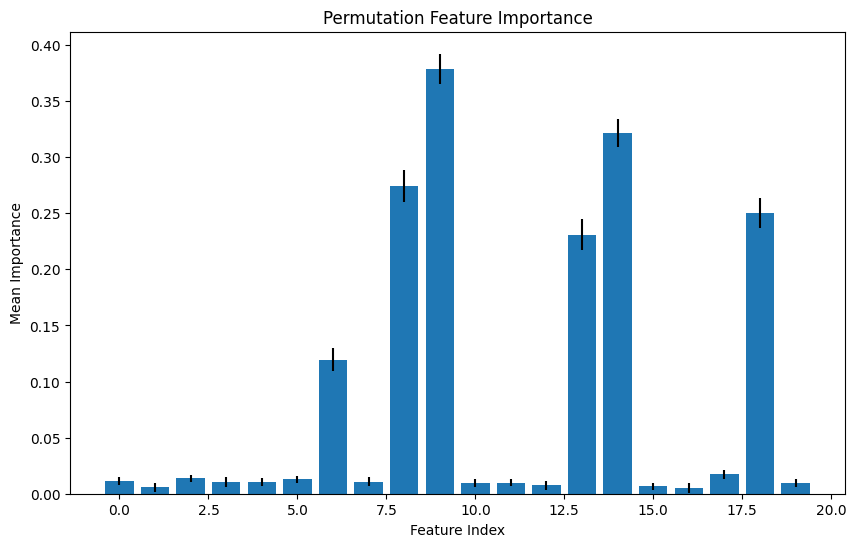

In [28]:
fig = plt.figure(figsize=(10, 6))
plt.bar(range(len(r.importances_mean)), r.importances_mean, yerr=r.importances_std)
plt.xlabel("Feature Index")
plt.ylabel("Mean Importance")
plt.title("Permutation Feature Importance")
plt.show()

In [29]:
r = permutation_importance(clf, X_test.cpu().numpy(), y_test.cpu().numpy(), n_repeats=100, random_state=0)

for i in r.importances_mean.argsort()[::-1]:
    print(f"{i:2} {r.importances_mean[i]:.3f} +/- {r.importances_std[i]:.3f}")

 9 0.372 +/- 0.014
14 0.313 +/- 0.012
 8 0.264 +/- 0.010
18 0.241 +/- 0.013
13 0.223 +/- 0.010
 6 0.121 +/- 0.011
10 0.012 +/- 0.003
17 0.011 +/- 0.003
 7 0.011 +/- 0.003
15 0.010 +/- 0.004
 2 0.010 +/- 0.003
12 0.009 +/- 0.004
 5 0.009 +/- 0.003
19 0.008 +/- 0.003
 3 0.008 +/- 0.003
 1 0.007 +/- 0.003
 4 0.007 +/- 0.004
16 0.006 +/- 0.003
 0 0.006 +/- 0.004
11 0.004 +/- 0.003


In [ ]:
def select_significant_features(clf, X, y, threshold=0.01):
    r = permutation_importance(clf, X.cpu().numpy(), y.cpu().numpy(), n_repeats=100, random_state=0)
    significant_indices = np.where(r.importances_mean > threshold)[0]
    return significant_indices

---

## Zadanie 2: Partial Dependency Plots

---

In [8]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split, KFold
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.inspection import permutation_importance
from sklearn.utils.validation import check_is_fitted

device = "cuda" if torch.cuda.is_available() else "cpu"

In [14]:
X,y = make_regression(
    n_samples=5000,
    n_features=20,
    random_state=42
)

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

In [15]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2)

In [9]:
class Regressor(nn.Module):
    def __init__(self, input_size, hidden_layers, output_size,dropout_rate=0.5):
        super().__init__()

        self.input = nn.Linear(input_size, hidden_layers[0])
        self.input_bn = nn.BatchNorm1d(hidden_layers[0])

        self.hidden = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_layers[i], hidden_layers[i+1]),
                nn.BatchNorm1d(hidden_layers[i+1]),
                nn.ReLU(),
                nn.Dropout(dropout_rate)
            ) for i in range(len(hidden_layers)-1)
        ])

        self.output = nn.Linear(hidden_layers[-1], output_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.input_bn(self.input(x)))

        for layer in self.hidden:
            x = layer(x)

        x = self.output(x)

        return x


In [10]:
def create_best_regressors(input_size, output_size):
    kf = KFold(n_splits=5, shuffle=True)

    def objective(trial: optuna.Trial):
        lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
        n_hidden = trial.suggest_int("n_hidden", 1, 3)
        hidden_layers = []
        for i in range(n_hidden):
            hidden_layer_size = trial.suggest_categorical(f"hidden_layer_{i}", [32, 64, 128, 256])
            hidden_layers.append(hidden_layer_size)
        
        dropout = trial.suggest_float("dropout", 0.1, 0.5)
        best_fold_val_loss = []

        for i, (train_idx, val_idx) in enumerate(kf.split(X_train_val)):
            X_train, X_val = X_train_val[train_idx], X_train_val[val_idx]
            y_train, y_val = y_train_val[train_idx], y_train_val[val_idx]

            model = Regressor(input_size=input_size, hidden_layers=hidden_layers, output_size=output_size, dropout_rate=dropout).to(device)
            loss_fn = nn.MSELoss()
            optimizer = optim.Adam(model.parameters(), lr=lr)
            best_val_loss = float('inf')
            train_losses = []
            val_losses = []

            train_loader = DataLoader(list(zip(X_train, y_train)), batch_size=256, shuffle=True)
            val_loader = DataLoader(list(zip(X_val, y_val)), batch_size=256)

            for epoch in range(30):
                train_loss = 0.0
                model.train()

                for X_batch, y_batch in train_loader:
                    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                    optimizer.zero_grad()
                    outputs = model(X_batch).squeeze()
                    loss = loss_fn(outputs, y_batch)
                    loss.backward()
                    optimizer.step()
                    train_loss += loss.item()
                
                train_loss /= len(train_loader)
                train_losses.append(train_loss)

                val_loss = 0.0
                with torch.inference_mode():
                    model.eval()
                    for X_batch, y_batch in val_loader:
                        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                        val_outputs = model(X_batch).squeeze()
                        val_loss += loss_fn(val_outputs, y_batch).item()

                    val_loss /= len(val_loader)
                    val_losses.append(val_loss)

                    if val_loss < best_val_loss:
                        best_val_loss = val_loss
                        dic = {
                            "model_state_dict": model.state_dict(),
                            "optimizer_state_dict": optimizer.state_dict(),
                            "val_loss": val_loss,
                            "hyperparameters": {
                                "lr": lr,
                                "hidden_layers": hidden_layers,
                                "dropout": dropout
                            }
                        }

                        os.makedirs(f"models/optuna_regression/trial_{trial.number}", exist_ok=True)
                        torch.save(dic, f"models/optuna_regression/trial_{trial.number}/best_model_fold_{i}.pth")
            best_fold_val_loss.append(best_val_loss)
        return np.mean(best_fold_val_loss)
    
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=20)

    with open("models/optuna_regression/best_trials.txt", "w") as f:
        best_trials = sorted(study.trials, key=lambda t: t.value)[:5]
        for t in best_trials:
            f.write(f"Trial {t.number}: Value (mean val loss) = {t.value}\n")
            f.write("Hyperparameters:\n")
            for key, value in t.params.items():
                f.write(f"  {key}: {value}\n")
            f.write("\n")

In [15]:
create_best_regressors(input_size=20, output_size=1)

[I 2026-06-03 06:52:08,350] A new study created in memory with name: no-name-144559e9-d72f-4321-bd0c-726af71f3df7
[I 2026-06-03 06:52:16,951] Trial 0 finished with value: 8416.286938476562 and parameters: {'lr': 0.0006243924462324159, 'n_hidden': 1, 'hidden_layer_0': 256, 'dropout': 0.4824242911494211}. Best is trial 0 with value: 8416.286938476562.
[I 2026-06-03 06:52:27,263] Trial 1 finished with value: 20645.479296875 and parameters: {'lr': 0.0001402432550900049, 'n_hidden': 2, 'hidden_layer_0': 256, 'hidden_layer_1': 256, 'dropout': 0.37172840268509943}. Best is trial 0 with value: 8416.286938476562.
[I 2026-06-03 06:52:31,997] Trial 2 finished with value: 2314.6455139160157 and parameters: {'lr': 0.0009876343463901393, 'n_hidden': 1, 'hidden_layer_0': 256, 'dropout': 0.34861795767697423}. Best is trial 2 with value: 2314.6455139160157.
[I 2026-06-03 06:52:38,197] Trial 3 finished with value: 25471.70419921875 and parameters: {'lr': 1.9667596063602427e-05, 'n_hidden': 2, 'hidden_la

In [11]:
# Best trial: 15
class RegressorWrapper(RegressorMixin,BaseEstimator):
    _estimator_type = "regressor"

    def __init__(self, best_trial = 15):
        self.best_trial = best_trial
    
    def fit(self, X, y):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.learning_rates_ = []
        self.models_ = []
        self.optimizers_ = []

        for i in range(5):
            path = f"models/optuna_regression/trial_{self.best_trial}/best_model_fold_{i}.pth"
            checkpoint = torch.load(path, map_location=self.device)

            model = Regressor(input_size=20, hidden_layers=checkpoint['hyperparameters']['hidden_layers'], output_size=1, dropout_rate=checkpoint['hyperparameters']['dropout']).to(self.device)
            model.load_state_dict(checkpoint['model_state_dict'])

            optimizer = optim.Adam(model.parameters(), lr=checkpoint['hyperparameters']['lr'])
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

            self.models_.append(model)
            self.optimizers_.append(optimizer)
            self.learning_rates_.append(checkpoint['hyperparameters']['lr'])
        
        self.is_fitted_ = True
            
        return self
    
    def ensemble(self, X):
        if hasattr(X, 'values'):
            X = X.values

        X_tensor = torch.tensor(X, dtype=torch.float32).to(self.device)
        val_loader = DataLoader(list(X_tensor), batch_size=256)
        
        all_preds = [] # lista tensorów (n_samples,)

        for model in self.models_:
            model.eval()
            with torch.inference_mode():
                preds_batches = []
                for X_batch in val_loader:
                    X_batch = X_batch.to(self.device)
                    outputs = model(X_batch).squeeze()
                    preds_batches.append(outputs)
                
                all_preds.append(torch.cat(preds_batches))# (n_samples,)

        preds_stack = torch.stack(all_preds, dim=0) # (n_models, n_samples)
        ensemble_preds = preds_stack.mean(dim=0) # (n_samples,)

        return ensemble_preds
    
    def predict(self, X):
        check_is_fitted(self, 'is_fitted_')
    
        preds = self.ensemble(X)

        return preds.cpu().numpy()
    
    def score(self, X, y):
        y_pred = self.predict(X)

        return -np.mean((y_pred - y.cpu().numpy())**2)
    
    def feature_importance(self, X, y, threshold=0.05):
        r = permutation_importance(self, X, y, n_repeats=100, random_state=0)
        
        lower_bound = r.importances_mean - 2 * r.importances_std
        upper_bound = r.importances_mean + 2 * r.importances_std

        significant_indices = np.where((lower_bound > threshold) | (upper_bound < -threshold))[0]

        print("Feature importances:")
        for i in r.importances_mean.argsort()[::-1]:
            lb = r.importances_mean[i] - 2 * r.importances_std[i]
            ub = r.importances_mean[i] + 2 * r.importances_std[i]
            print(f"{i:2} {r.importances_mean[i]:.3f} +/- {r.importances_std[i]:.3f}")
            print(f"95% CI: [{lb:.3f}, {ub:.3f}] {'Significant' if i in significant_indices else 'Not Significant'}")

        return significant_indices

In [16]:
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2)

In [20]:
reg = RegressorWrapper(best_trial=15)
reg.fit(X_train.cpu().numpy(), y_train.cpu().numpy())

FileNotFoundError: [Errno 2] No such file or directory: 'models/optuna_regression/trial_15/best_model_fold_0.pth'

In [44]:
feature_importances = reg.feature_importance(X_val, y_val, threshold=0.05)
print("Significant feature indices:", feature_importances)

Feature importances:
 1 12896.492 +/- 490.667
95% CI: [11915.158, 13877.826] Significant
16 11293.322 +/- 383.344
95% CI: [10526.634, 12060.011] Significant
17 8572.078 +/- 362.990
95% CI: [7846.098, 9298.059] Significant
14 6635.639 +/- 215.603
95% CI: [6204.432, 7066.846] Significant
13 4942.020 +/- 166.515
95% CI: [4608.989, 5275.051] Significant
19 1949.026 +/- 70.219
95% CI: [1808.588, 2089.464] Significant
 8 1328.584 +/- 48.812
95% CI: [1230.960, 1426.208] Significant
10 753.263 +/- 26.693
95% CI: [699.876, 806.650] Significant
15 162.446 +/- 6.778
95% CI: [148.889, 176.002] Significant
18 6.682 +/- 0.346
95% CI: [5.989, 7.374] Significant
 2 0.095 +/- 0.073
95% CI: [-0.052, 0.242] Not Significant
 5 0.053 +/- 0.046
95% CI: [-0.038, 0.145] Not Significant
 7 0.047 +/- 0.088
95% CI: [-0.128, 0.222] Not Significant
 0 0.037 +/- 0.086
95% CI: [-0.136, 0.209] Not Significant
 3 0.033 +/- 0.058
95% CI: [-0.083, 0.148] Not Significant
 4 0.011 +/- 0.048
95% CI: [-0.086, 0.108] Not Sig

In [12]:
from sklearn.inspection import PartialDependenceDisplay
from sklearn.base import is_regressor

In [61]:
is_regressor(reg)

True

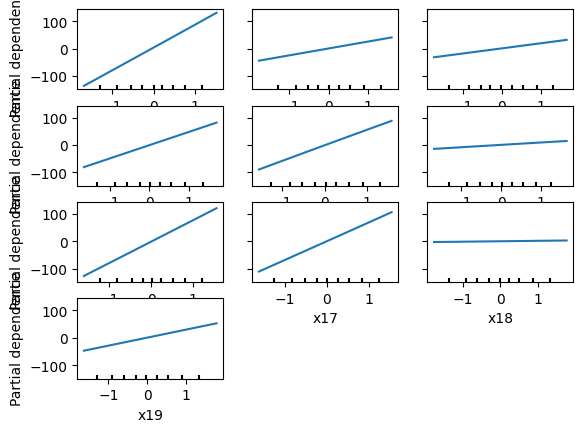

In [67]:
PartialDependenceDisplay.from_estimator(reg, X_val.cpu().numpy(), features=feature_importances)

In [68]:
features_to_remove = [8,10,15,18]

In [69]:
new_features = [feature for feature in feature_importances if feature not in features_to_remove]

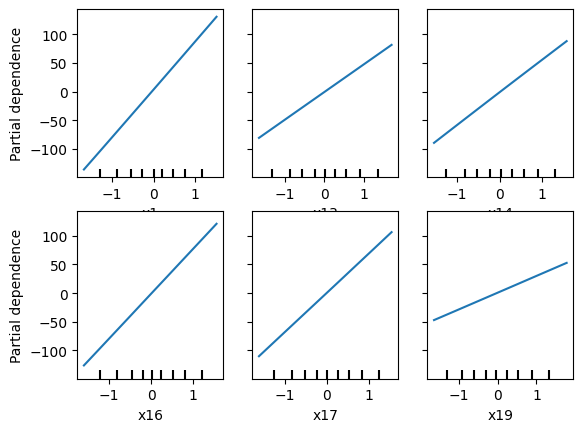

In [70]:
PartialDependenceDisplay.from_estimator(reg, X_val.cpu().numpy(), features=new_features)

---

## Zadanie 3: LIME dla toy set

### Krok 1-2: Generowanie perturbacji i trening modelu WLS

Dla wybranego punktu `X_test[0]` generujemy perturbacje (szum gaussowski skalowany przez std cech),
obliczamy wagi odleglosci i trenujemy wazony model liniowy (WLS) z `statsmodels`.

In [17]:
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.inspection import permutation_importance


In [18]:
# Odtworzenie podziau train/val (spójne z Zadaniem 2)
from sklearn.model_selection import KFold
kf_z3 = KFold(n_splits=5, shuffle=True)
train_idx_z3, val_idx_z3 = next(iter(kf_z3.split(X_train_val)))
X_train_z3 = X_train_val[train_idx_z3]
X_val_z3   = X_train_val[val_idx_z3]
print(f'X_train_z3 shape: {X_train_z3.shape}, X_test shape: {X_test.shape}')


X_train_z3 shape: torch.Size([3200, 20]), X_test shape: torch.Size([1000, 20])


In [19]:
def lime_explain(model, X_point, X_train, n_pert=1000, pert_factor=0.3):
    '''
    Wyznacza wagi cech metoda LIME dla pojedynczego punktu X_point.

    Parametry
    ---------
    model        : sklearn-kompatybilny regresor (z metoda predict)
    X_point      : torch.Tensor, ksztalt (n_features,)
    X_train      : torch.Tensor, ksztalt (n_samples, n_features)
    n_pert       : liczba perturbacji
    pert_factor  : wspolczynnik skalowania szumu wzgledem std cechy

    Zwraca
    ------
    result : statsmodels WLS RegressionResultsWrapper
    '''
    import torch
    stds = X_train.std(dim=0)                                       # std cech ze zbioru treningowego

    # Perturbacje: (n_features, n_pert) -> (n_pert, n_features)
    noise = torch.randn((X_point.shape[0], n_pert)) * stds.unsqueeze(1) * pert_factor
    perturbations = (X_point.unsqueeze(1) + noise).swapaxes(0, 1)  # (n_pert, n_features)

    # Odpowiedzi modelu na perturbacje
    outputs = model.predict(perturbations.numpy())                  # (n_pert,)

    # Wagi: eksponencjalna odleglosc od punktu bazowego
    sample    = X_point.numpy()
    distances = np.exp(-np.linalg.norm(perturbations.numpy() - sample, axis=1))

    # Trening wazonego modelu liniowego (WLS) z interceptem
    X_const = sm.add_constant(perturbations.numpy())
    result  = sm.WLS(outputs, X_const, weights=distances).fit()
    return result


# --- Wyjaśnienie dla pierwszego przykladu testowego ---
X_point_0     = X_test[0]
result_single = lime_explain(reg, X_point_0, X_train_z3, n_pert=1000)

print('=' * 55)
print('LIME - wyjaśnienie dla X_test[0]')
print('=' * 55)
print(f'R^2       : {result_single.rsquared:.4f}')
print(f'Adj. R^2  : {result_single.rsquared_adj:.4f}')


NameError: name 'reg' is not defined

### Krok 3: Jakosc modelu liniowego – R2

Wysokie R2 (bliskie 1) oznacza, ze model WLS dobrze przybliza zachowanie sieci neuronowej w otoczeniu punktu.

In [ ]:
r2 = result_single.rsquared
if r2 > 0.9:
    label = 'Bardzo dobre lokalne przyblizenie – wyjasnienia wiarygodne.'
elif r2 > 0.7:
    label = 'Dobre lokalne przyblizenie.'
else:
    label = 'Slabe przyblizenie – wyjasnienia naleza interpretowac ostrozenie.'
print(f'R^2 = {r2:.4f}  →  {label}')
print()
print(result_single.summary())


### Krok 4: Wagi cech na podstawie statystyki t (X_test[0])

Cechy istotne statystycznie (p < 0.05) oznaczone `*`. Sortowanie malejace wg |t|.

In [ ]:
n_features = X_train_z3.shape[1]
tvalues = result_single.tvalues[1:]   # indeks 0 to intercept
pvalues = result_single.pvalues[1:]
coefs   = result_single.params[1:]

header = f"{'Cecha':>6}  {'Coef':>10}  {'t-stat':>10}  {'p-value':>10}  Istotna"
print(header)
print('-' * 60)
for i in np.argsort(np.abs(tvalues))[::-1]:
    sig = '*' if pvalues[i] < 0.05 else ''
    print(f'{i:>6}  {coefs[i]:>10.4f}  {tvalues[i]:>10.4f}  {pvalues[i]:>10.4f}  {sig}')


### Krok 5: Srednie wagi cech na calym zbiorze testowym

Powielamy LIME dla kazdego przykladu testowego (n_pert=500 dla szybkosci) i usredniamy wagi – uzyskujac globalny ranking istotnosci porownywalna z PFI.

In [ ]:
n_test      = X_test.shape[0]
all_tvalues = np.zeros((n_test, n_features))
all_coefs   = np.zeros((n_test, n_features))
all_r2      = np.zeros(n_test)

print('Obliczanie LIME dla calego zbioru testowego...')
for idx in tqdm(range(n_test)):
    res = lime_explain(reg, X_test[idx], X_train_z3, n_pert=500)
    all_tvalues[idx] = res.tvalues[1:]
    all_coefs[idx]   = res.params[1:]
    all_r2[idx]      = res.rsquared

mean_abs_t = np.mean(np.abs(all_tvalues), axis=0)
mean_coefs = np.mean(all_coefs,            axis=0)
std_coefs  = np.std(all_coefs,             axis=0)

print(f'Srednie R^2 na zbiorze testowym: {all_r2.mean():.4f} +/- {all_r2.std():.4f}')
print()
header2 = f"{'Cecha':>6}  {'Sr. coef':>10}  {'Std coef':>10}  {'Sr. |t|':>10}"
print(header2)
print('-' * 50)
for i in np.argsort(mean_abs_t)[::-1]:
    print(f'{i:>6}  {mean_coefs[i]:>10.4f}  {std_coefs[i]:>10.4f}  {mean_abs_t[i]:>10.4f}')


### Porownanie LIME vs Permutation Feature Importance

Zestawiamy znormalizowane wagi LIME z wynikami PFI z Zadania 2 na wykresach slupkowych i diagramie rozrzutu.

In [ ]:
# PFI na zbiorze testowym
r_pfi    = permutation_importance(reg, X_test.numpy(), y_test.numpy(), n_repeats=30, random_state=42)
pfi_mean = r_pfi.importances_mean

# Normalizacja do [0,1] dla wspolnej skali
lime_norm = mean_abs_t / (mean_abs_t.max() + 1e-9)
pfi_norm  = pfi_mean   / (np.abs(pfi_mean).max() + 1e-9)
labels    = [f'x{i}' for i in range(n_features)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Wykres LIME ---
ord_l = np.argsort(lime_norm)[::-1]
axes[0].bar(range(n_features), lime_norm[ord_l], color='steelblue')
axes[0].set_xticks(range(n_features))
axes[0].set_xticklabels([labels[i] for i in ord_l], rotation=45, ha='right')
axes[0].set_title('LIME – znorm. srednia |t-stat|')
axes[0].set_xlabel('Cecha')
axes[0].set_ylabel('Waga (znorm.)')

# --- Wykres PFI ---
ord_p = np.argsort(pfi_norm)[::-1]
cols  = ['steelblue' if v >= 0 else 'tomato' for v in pfi_norm[ord_p]]
axes[1].bar(range(n_features), pfi_norm[ord_p], color=cols)
axes[1].set_xticks(range(n_features))
axes[1].set_xticklabels([labels[i] for i in ord_p], rotation=45, ha='right')
axes[1].set_title('Permutation Feature Importance (zbior testowy)')
axes[1].set_xlabel('Cecha')
axes[1].set_ylabel('Waznosc (znorm.)')

plt.suptitle('LIME vs Permutation Feature Importance', fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
# Diagram korelacji LIME vs PFI
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(lime_norm, pfi_norm, color='steelblue', edgecolors='navy', s=80, alpha=0.85)
for i in range(n_features):
    ax.annotate(f'x{i}', (lime_norm[i], pfi_norm[i]),
                textcoords='offset points', xytext=(5, 5), fontsize=8)

corr = np.corrcoef(lime_norm, pfi_norm)[0, 1]
ax.set_title(f'Korelacja LIME vs PFI  (r = {corr:.3f})')
ax.set_xlabel('LIME (znorm. sr. |t|)')
ax.set_ylabel('PFI (znorm.)')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

top5_l = set(np.argsort(lime_norm)[::-1][:5])
top5_p = set(np.argsort(pfi_norm)[::-1][:5])
overlap = top5_l & top5_p
print(f'r Pearson  LIME vs PFI : {corr:.4f}')
print(f'Top-5 wg LIME : {sorted(top5_l)}')
print(f'Top-5 wg PFI  : {sorted(top5_p)}')
print(f'Wspolne cechy : {sorted(overlap)}  ({len(overlap)}/5 zgodnych)')


### Wnioski

**Metoda LIME:**
- Lokalne wyjasnienia oparte na modelu WLS trenowanym w otoczeniu wyjasninego punktu.
- R^2 informuje o jakosci lokalnego przyblizenia – niskie R^2 oznacza, ze siec jest zbyt nieliniowa lokalnie.
- Globalizacja przez usrednianie po zbiorze testowym daje globalny ranking istotnosci.

**Porownanie LIME vs PFI:**
- PFI (globalna) mierzy degradacje dokladnosci po permutacji cechy; LIME (lokalna) modeluje wrazliwosc liniowa wokol danego punktu.
- Wysoka korelacja (r bliskie 1) potwierdza zgodnosc rankingu obu metod.
- Rozbieznosci wskazuja na silne efekty nieliniowe lub interakcje miedzy cechami, ktore model liniowy LIME slabo uchwytuje.

---